In [1]:
import pandas as pd

df = pd.read_csv("water_potability.csv")
df.head(5)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [2]:
import matplotlib.pyplot as plt

print(df.shape)
print(df.dtypes)
display(df.describe())


(3276, 10)
ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


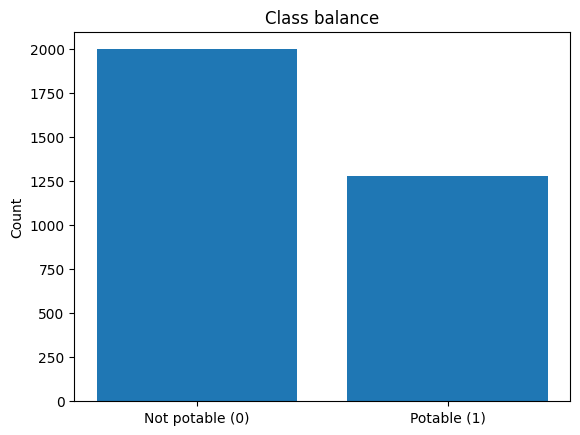

In [3]:
target_counts = df["Potability"].value_counts().sort_index()
plt.figure()
plt.bar(["Not potable (0)", "Potable (1)"], target_counts.values)
plt.title("Class balance")
plt.ylabel("Count")
plt.show()

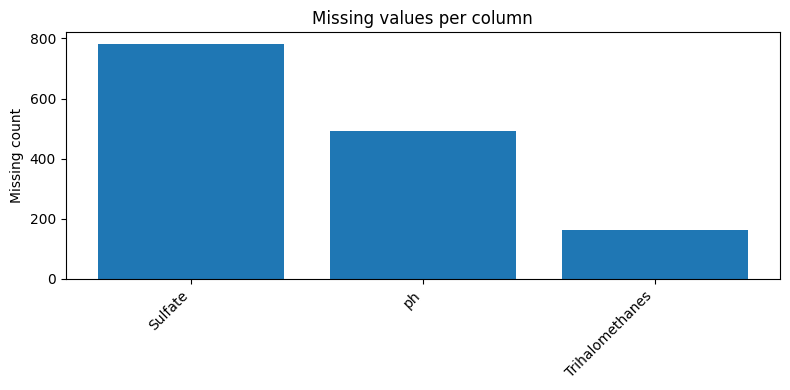

In [4]:
import numpy as np

na_count = df.isna().sum().sort_values(ascending=False)
na_count = na_count[na_count > 0]


plt.figure(figsize=(8, 4))
plt.bar(na_count.index, na_count.values)
plt.title("Missing values per column")
plt.ylabel("Missing count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


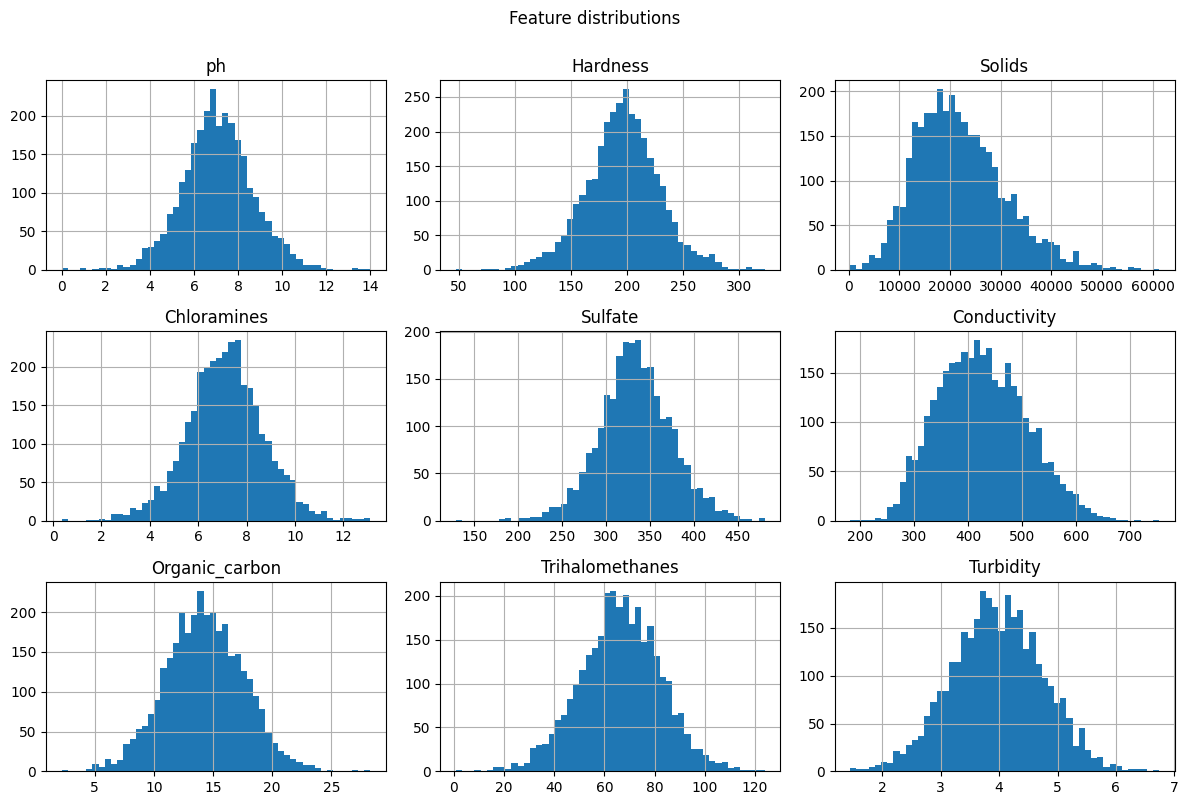

In [5]:
#histograms
features = [c for c in df.columns if c != "Potability"]

df[features].hist(bins=50, figsize=(12,8))
plt.suptitle("Feature distributions", y=1)
plt.tight_layout()
plt.show()

<Figure size 1200x800 with 0 Axes>

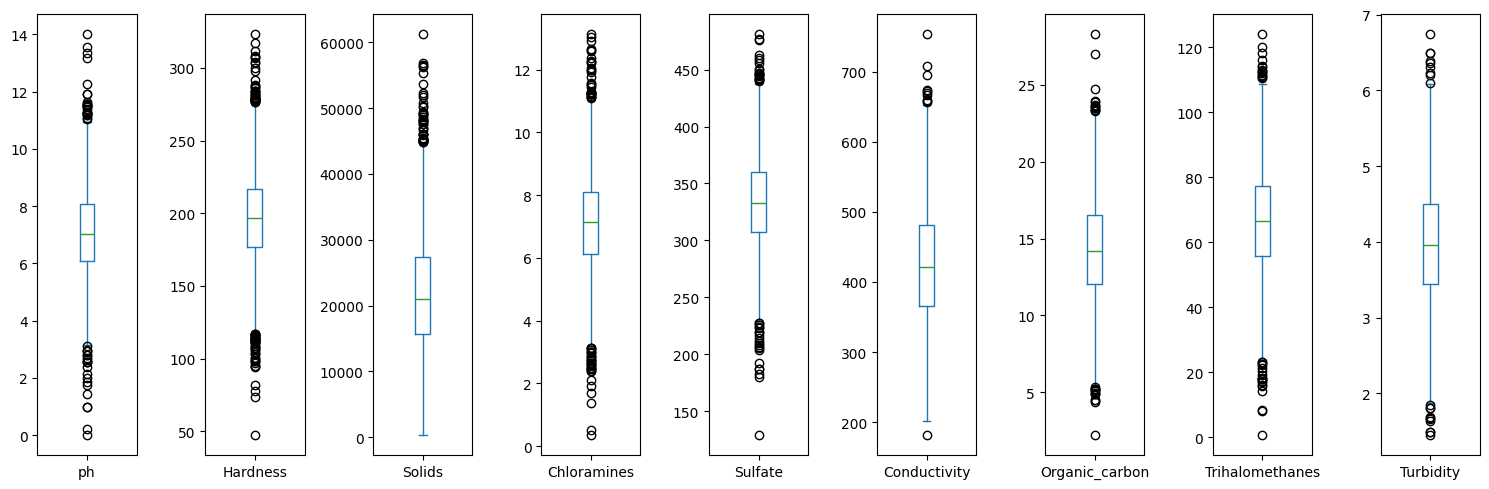

In [6]:
#boxplots

plt.figure(figsize=(12,8))
df[features].plot(kind='box', subplots=True, sharey=False, figsize=(15, 5))
plt.tight_layout()
plt.show()

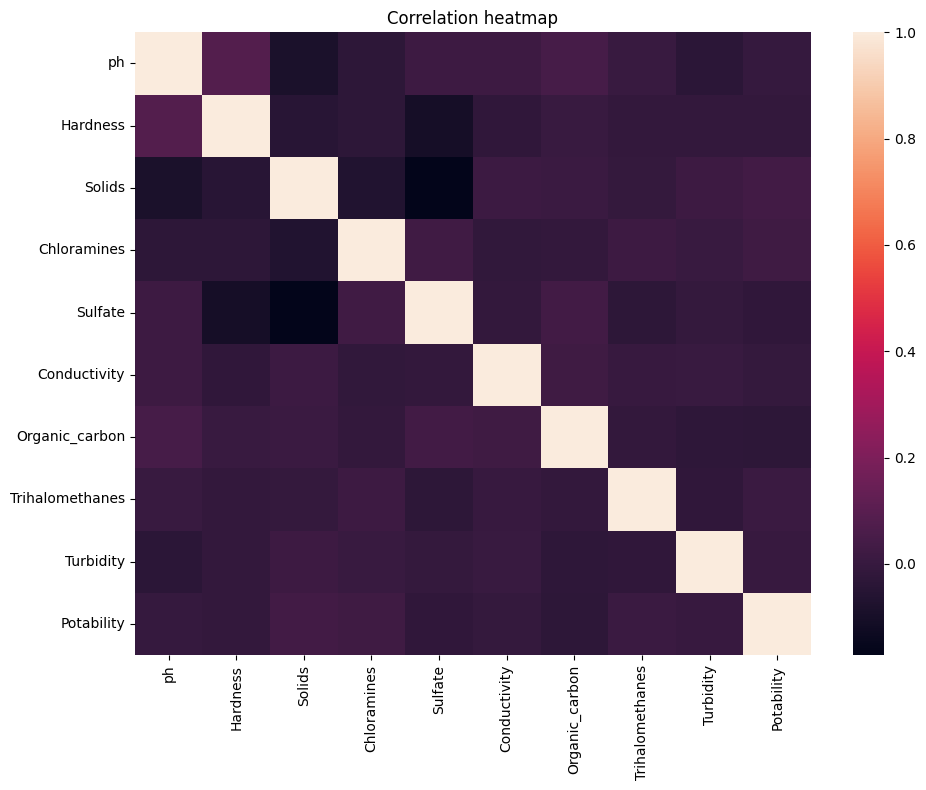

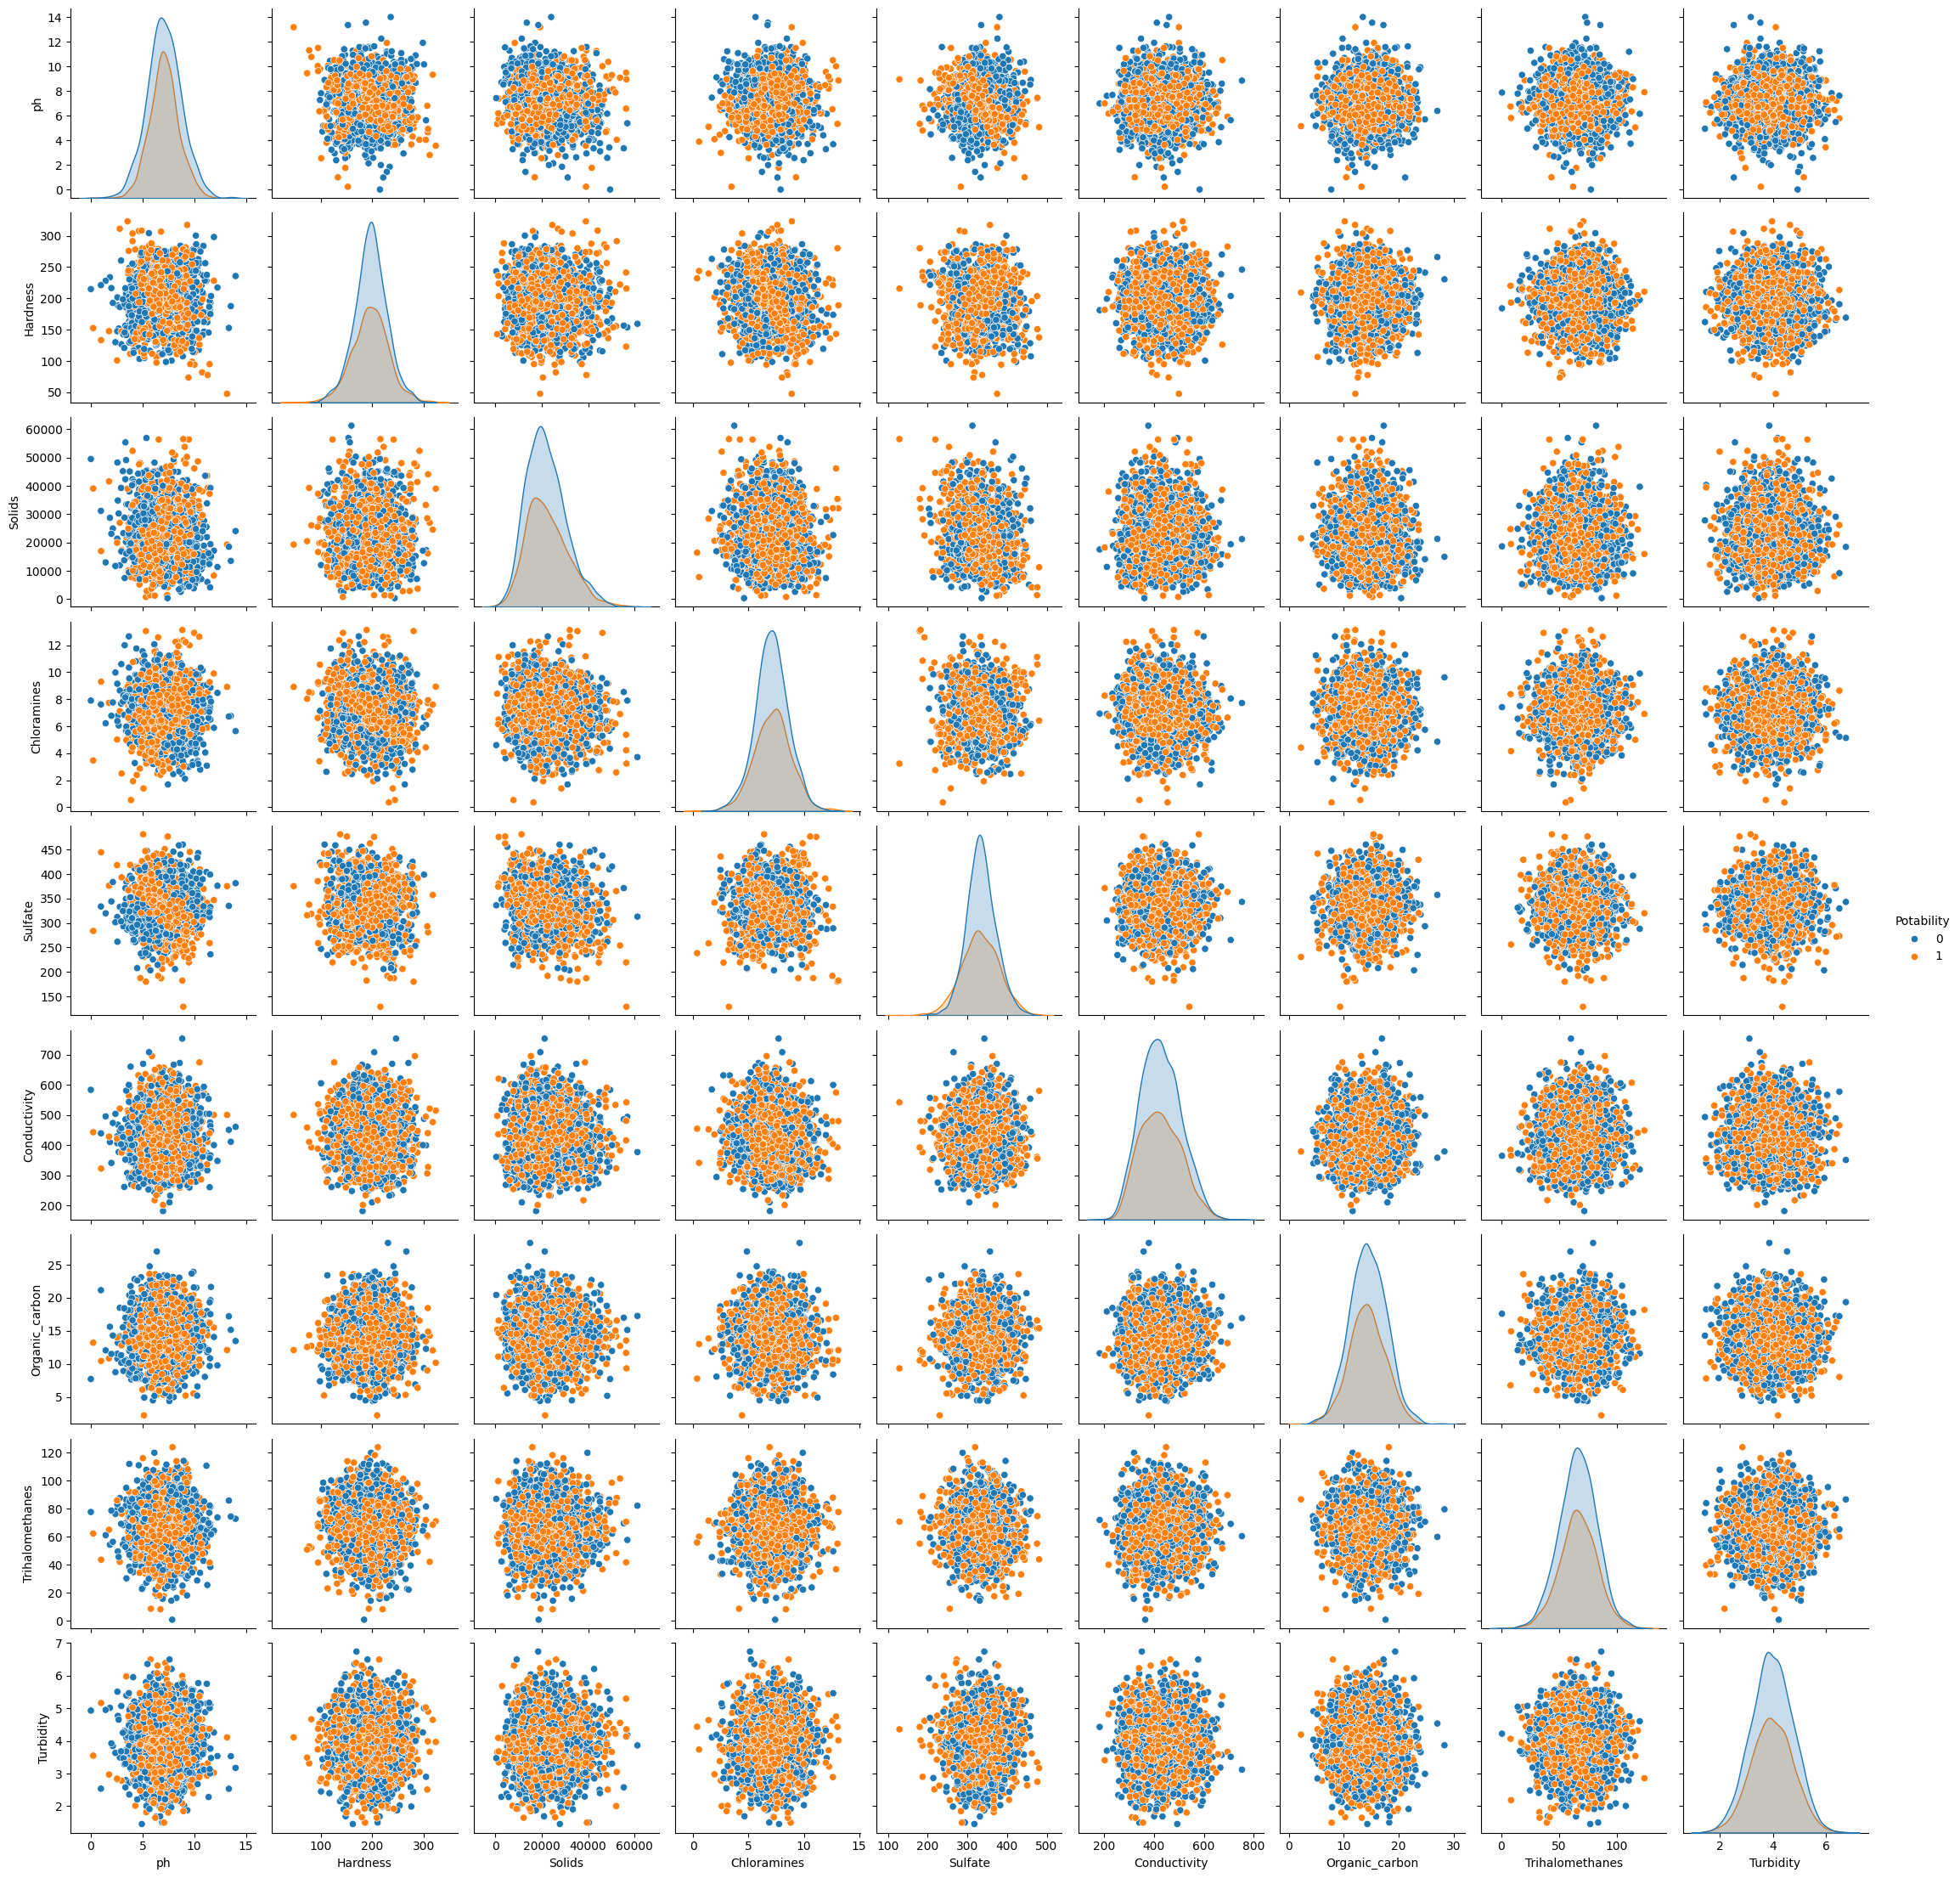

In [7]:
import seaborn as sb
plt.figure(figsize=(10, 8))
sb.heatmap(df[features + ["Potability"]].corr(), annot=False)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

import seaborn as sns

sns.pairplot(df, hue = 'Potability');

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer

X = df.drop("Potability", axis=1)
y = df["Potability"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

num_features = X.columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
     ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler())
        ]), num_features)
    ],
    remainder="drop"
)

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier



models = {
    "LogReg": LogisticRegression(),
    "SVM": SVC(),
    "RandomForest": RandomForestClassifier(),
    "GradientBoosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "DecisionTree": DecisionTreeClassifier()
}

pipelines = {
    name: Pipeline(steps=[("prep", preprocess), ("model", model)])
    for name, model in models.items()
}


In [10]:

from sklearn.metrics import classification_report




for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)

    print(f"\n=== {name} ===")
    y_pred = pipe.predict(X_test)
    print(classification_report(y_test, y_pred))



=== LogReg ===
              precision    recall  f1-score   support

           0       0.61      1.00      0.76       400
           1       0.00      0.00      0.00       256

    accuracy                           0.61       656
   macro avg       0.30      0.50      0.38       656
weighted avg       0.37      0.61      0.46       656


=== SVM ===
              precision    recall  f1-score   support

           0       0.67      0.92      0.77       400
           1       0.68      0.29      0.40       256

    accuracy                           0.67       656
   macro avg       0.67      0.60      0.59       656
weighted avg       0.67      0.67      0.63       656



/home/codemancydev/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/codemancydev/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/codemancydev/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh


=== RandomForest ===
              precision    recall  f1-score   support

           0       0.67      0.91      0.77       400
           1       0.68      0.30      0.42       256

    accuracy                           0.67       656
   macro avg       0.67      0.61      0.60       656
weighted avg       0.67      0.67      0.63       656


=== GradientBoosting ===
              precision    recall  f1-score   support

           0       0.65      0.91      0.76       400
           1       0.64      0.25      0.36       256

    accuracy                           0.65       656
   macro avg       0.65      0.58      0.56       656
weighted avg       0.65      0.65      0.60       656


=== KNN ===
              precision    recall  f1-score   support

           0       0.65      0.80      0.72       400
           1       0.51      0.32      0.40       256

    accuracy                           0.61       656
   macro avg       0.58      0.56      0.56       656
weighted avg 

In [11]:
# notes
#do cross validation
#keep to one split truought the whole exxperiment
#procentulano outliers do the math analysis (look it up)
#stratified split , keep the class raspodelu ocuvanu

#models tuned

param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [None, 8, 12, 16],
    "min_samples_leaf": [1, 5, 10],
    "max_features": ["sqrt", "log2"]
}

rf_search = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    scoring="accuracy",   
    cv=5,
    n_jobs=-1
)

models = {
    "LogReg": LogisticRegression(max_iter=3000, class_weight="balanced"),
    "SVM": SVC(class_weight="balanced",C=1.0,gamma="scale", probability=True),
    "RandomForest": rf_search,
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
    "KNN": KNeighborsClassifier(n_neighbors=15, weights="distance")
}

pipelines = {
    name: Pipeline(steps=[("prep", preprocess), ("model", model)])
    for name, model in models.items()
}



for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)

    print(f"\n=== {name} ===")
    y_pred = pipe.predict(X_test)
    print(classification_report(y_test, y_pred))


=== LogReg ===
              precision    recall  f1-score   support

           0       0.63      0.52      0.57       400
           1       0.41      0.53      0.47       256

    accuracy                           0.52       656
   macro avg       0.52      0.53      0.52       656
weighted avg       0.55      0.52      0.53       656


=== SVM ===
              precision    recall  f1-score   support

           0       0.68      0.70      0.69       400
           1       0.51      0.49      0.50       256

    accuracy                           0.62       656
   macro avg       0.60      0.60      0.60       656
weighted avg       0.62      0.62      0.62       656


=== RandomForest ===
              precision    recall  f1-score   support

           0       0.66      0.94      0.77       400
           1       0.71      0.23      0.35       256

    accuracy                           0.66       656
   macro avg       0.68      0.59      0.56       656
weighted avg       0.68

<Figure size 1200x800 with 0 Axes>

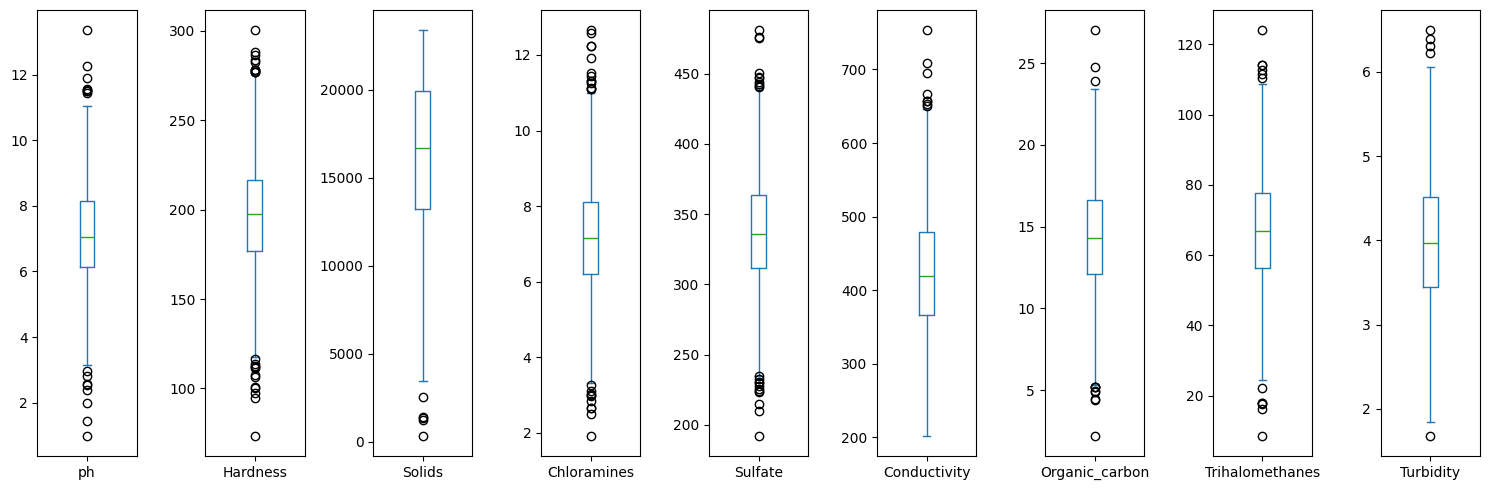


=== LogReg ===
              precision    recall  f1-score   support

           0       0.64      0.90      0.75       147
           1       0.58      0.22      0.32        96

    accuracy                           0.63       243
   macro avg       0.61      0.56      0.53       243
weighted avg       0.62      0.63      0.58       243


=== SVM ===
              precision    recall  f1-score   support

           0       0.67      0.88      0.76       147
           1       0.65      0.32      0.43        96

    accuracy                           0.66       243
   macro avg       0.66      0.60      0.60       243
weighted avg       0.66      0.66      0.63       243


=== RandomForest ===
              precision    recall  f1-score   support

           0       0.80      0.93      0.86       147
           1       0.86      0.65      0.74        96

    accuracy                           0.82       243
   macro avg       0.83      0.79      0.80       243
weighted avg       0.82

In [15]:
#Making a copy of the data and removing outliers to see if it improves the results
from sklearn.preprocessing import StandardScaler

# KMeansClustering - delete outlier
from sklearn.cluster import KMeans
df.dropna(axis = 0, inplace = True)
kmeans = KMeans(n_clusters = 2)
kmeans.fit(df)
labels = kmeans.labels_
df2 = df[labels == 1]
df2.reset_index(inplace = True)


plt.figure(figsize=(12,8))
df2[features].plot(kind='box', subplots=True, sharey=False, figsize=(15, 5))
plt.tight_layout()
plt.show()

X = df2.drop("Potability", axis=1)
y = df2["Potability"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

models = {
    "LogReg": LogisticRegression(max_iter=5000, solver="saga"),
    "SVM": SVC(),
    "RandomForest": RandomForestClassifier(),
    "GradientBoosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "DecisionTree": DecisionTreeClassifier()
}

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred))





In [16]:
#do cross validation
#try different scalers
# try undersampling(random) or oversampling (SMOTE)

In [21]:
from sklearn.model_selection import cross_val_score, KFold

num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

models = {
    "LogReg": LogisticRegression(max_iter=10000, solver="sag"),
    "SVM": SVC(),
    "RandomForest": RandomForestClassifier(),
    "GradientBoosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "DecisionTree": DecisionTreeClassifier()
}

for name, model in models.items():
    cross_val_results = cross_val_score(model, X, y, cv=kf)
    print(f"\nCross-Validation Results (Accuracy) === {name} ===")
    for i, result in enumerate(cross_val_results, 1):
            print(f"  Fold {i}: {result * 100:.2f}%")
    print(f'Mean Accuracy: {cross_val_results.mean()* 100:.2f}%')


Cross-Validation Results (Accuracy) === LogReg ===
  Fold 1: 55.97%
  Fold 2: 59.67%
  Fold 3: 64.20%
  Fold 4: 64.61%
  Fold 5: 59.67%
Mean Accuracy: 60.82%

Cross-Validation Results (Accuracy) === SVM ===
  Fold 1: 55.14%
  Fold 2: 60.49%
  Fold 3: 61.73%
  Fold 4: 66.26%
  Fold 5: 58.02%
Mean Accuracy: 60.33%

Cross-Validation Results (Accuracy) === RandomForest ===
  Fold 1: 72.84%
  Fold 2: 83.13%
  Fold 3: 84.77%
  Fold 4: 83.13%
  Fold 5: 81.07%
Mean Accuracy: 80.99%

Cross-Validation Results (Accuracy) === GradientBoosting ===
  Fold 1: 99.18%
  Fold 2: 99.18%
  Fold 3: 98.35%
  Fold 4: 100.00%
  Fold 5: 99.18%
Mean Accuracy: 99.18%

Cross-Validation Results (Accuracy) === KNN ===
  Fold 1: 50.21%
  Fold 2: 51.44%
  Fold 3: 48.15%
  Fold 4: 54.73%
  Fold 5: 57.61%
Mean Accuracy: 52.43%

Cross-Validation Results (Accuracy) === AdaBoost ===
  Fold 1: 73.66%
  Fold 2: 75.72%
  Fold 3: 77.78%
  Fold 4: 84.36%
  Fold 5: 76.95%
Mean Accuracy: 77.70%

Cross-Validation Results (Accura

In [ ]:
#speed up
#do feature selection
#explainable ai